# Lizard Images Classification — Exploratory Data Analysis
This notebook covers EDA and baseline model setup for the lizard classification challenge.  
We start by thoroughly inspecting the raw data (file index, dimensions, corruptions, class balance) and then build a MobileNetV2-based transfer-learning pipeline with fine-tuning and evaluation.

> **Generative AI use:** portions of this notebook were drafted with AI assistance.

## 1. Import Libraries

In [16]:
import os
import gc
import glob
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Define Paths & Load Metadata
We load the CSV labels and the Excel class-name mapping, then preview both.

In [2]:
TRAIN_DIR  = "train"
TEST_DIR   = "test"
TRAIN_CSV  = "train.csv"
TEST_CSV   = "test.csv"
CLASSES_XLSX = "Classes_nummering.xlsx"

train_df   = pd.read_csv(TRAIN_CSV)
test_df    = pd.read_csv(TEST_CSV)
classes_df = pd.read_excel(CLASSES_XLSX)
classes_df.columns = ["Class", "Class_name"]

label_map = dict(zip(classes_df["Class"], classes_df["Class_name"]))

print("Train records:", len(train_df))
display(train_df.head())
display(classes_df)

Train records: 1334


,id,label
0,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
1,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
2,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
3,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
4,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0


,Class,Class_name
0,0,Black_spiny_tailed_iguana
1,1,Brown_anole
2,2,Cuban_knight_anole
3,3,Desert_iguana
4,4,Green_anole
5,5,Green_iguana
6,6,Lesser_Antillean_iguana


## 3. Build a Unified Dataset Index
Walk the training directory to build a DataFrame that maps every image to its label and file path.  
We also retrieve image dimensions and aspect ratios for downstream analysis.

In [3]:
data = []

for class_name in os.listdir(TRAIN_DIR):
    class_path = os.path.join(TRAIN_DIR, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        data.append({
            "image_id": img_name,
            "path":     img_path,
            "label":    class_name,
            "split":    "train",
        })

train_index = pd.DataFrame(data)
print(f"Total training images found: {len(train_index)}")
display(train_index.head())
print("\nImages per class:")
print(train_index["label"].value_counts())

Total training images found: 1334


,image_id,path,label,split
0,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,train\Black_spiny_tailed_iguana\Black_spiny-ta...,Black_spiny_tailed_iguana,train
1,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,train\Black_spiny_tailed_iguana\Black_spiny-ta...,Black_spiny_tailed_iguana,train
2,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,train\Black_spiny_tailed_iguana\Black_spiny-ta...,Black_spiny_tailed_iguana,train
3,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,train\Black_spiny_tailed_iguana\Black_spiny-ta...,Black_spiny_tailed_iguana,train
4,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,train\Black_spiny_tailed_iguana\Black_spiny-ta...,Black_spiny_tailed_iguana,train



Images per class:
label
Black_spiny_tailed_iguana    199
Green_iguana                 196
Lesser_Antillean_iguana      196
Brown_anole                  193
Cuban_knight_anole           189
Desert_iguana                183
Green_anole                  178
Name: count, dtype: int64


## 4. Class Distribution
A horizontal count-plot gives an intuitive view of any class imbalance.

C:\Users\Jeff\AppData\Local\Temp\ipykernel_32072\4138037716.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_index, y="label", order=order, palette="viridis")


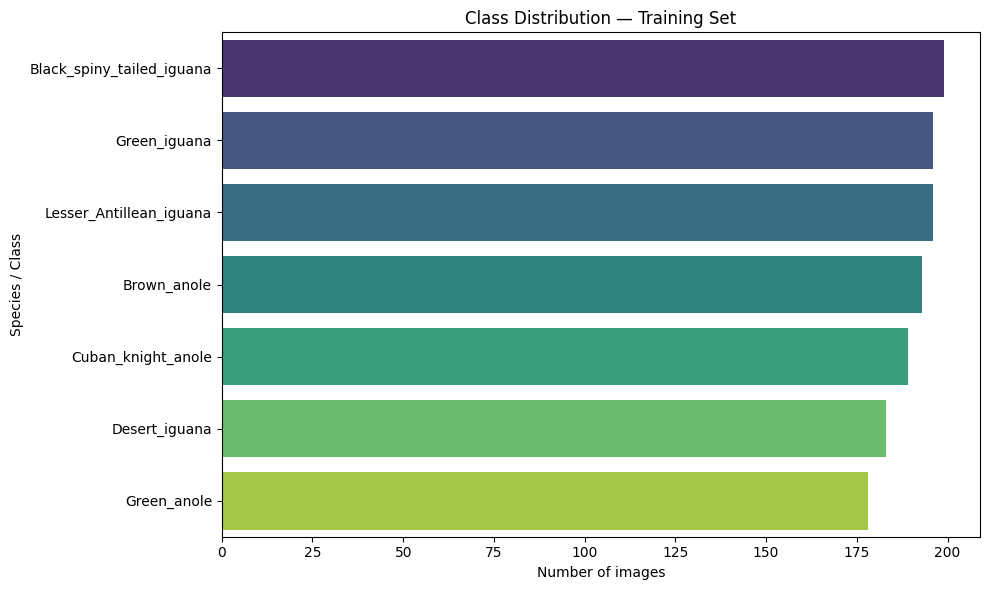

In [4]:
plt.figure(figsize=(10, 6))
order = train_index["label"].value_counts().index
sns.countplot(data=train_index, y="label", order=order, palette="viridis")
plt.title("Class Distribution — Training Set")
plt.xlabel("Number of images")
plt.ylabel("Species / Class")
plt.tight_layout()
plt.show()

## 5. Visual Inspection per Class
We display five random sample images for every class so we can spot quality issues or mislabelled examples at a glance.

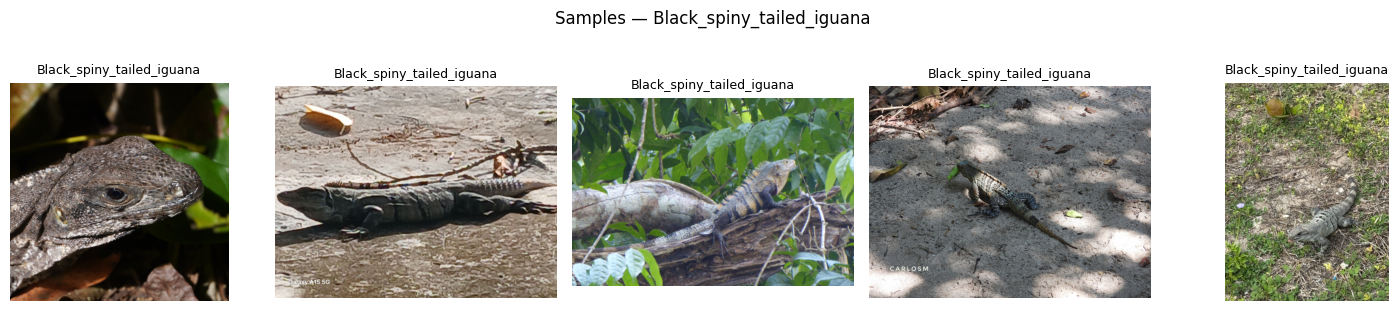

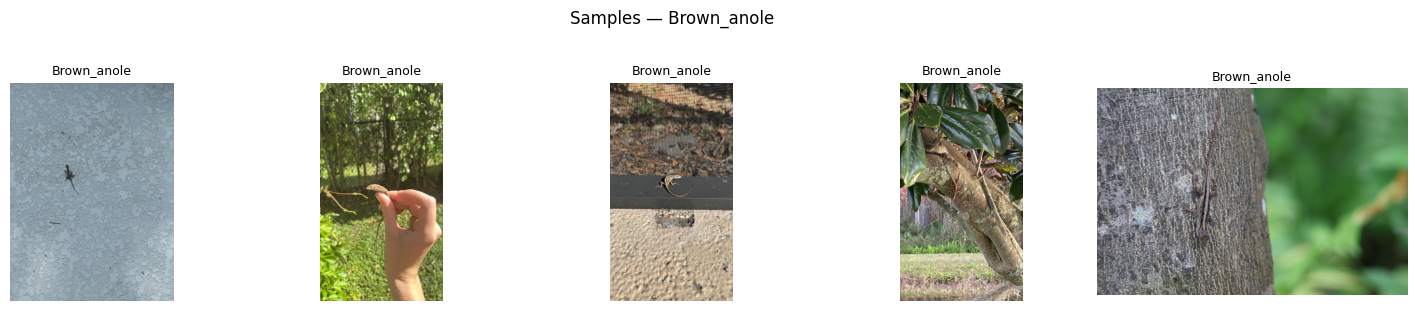

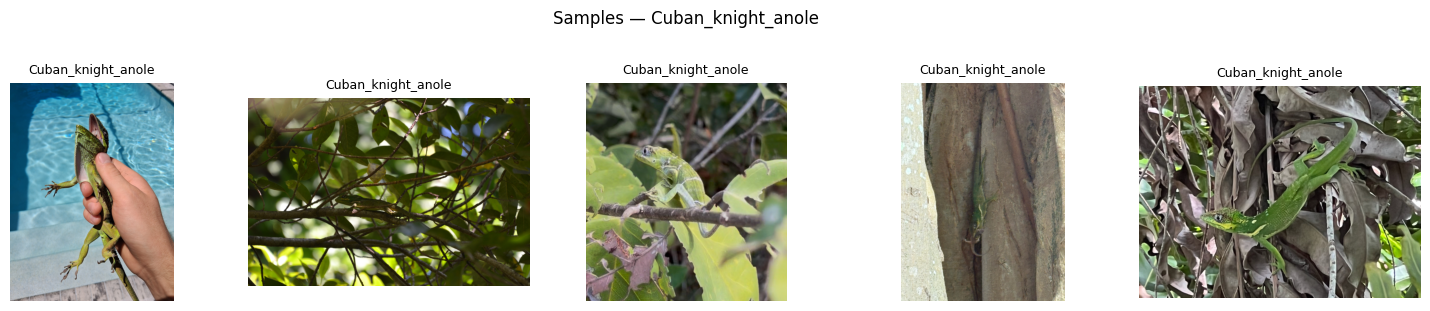

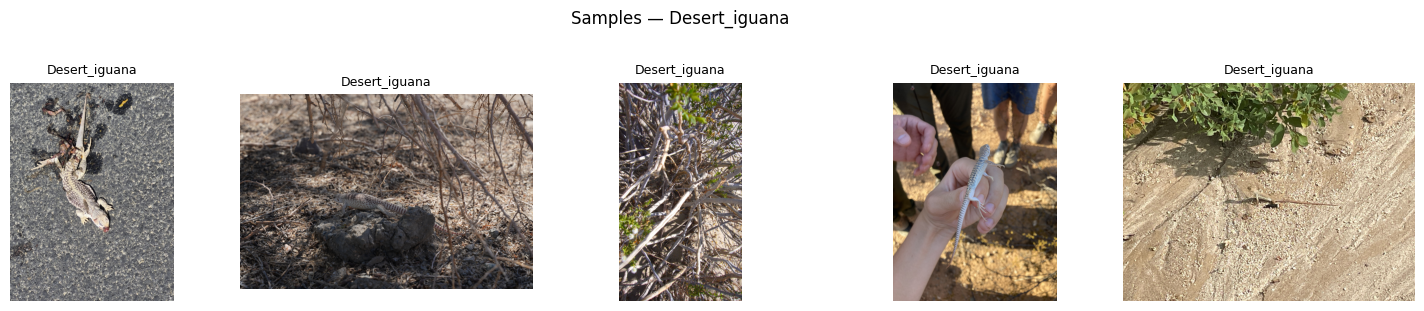

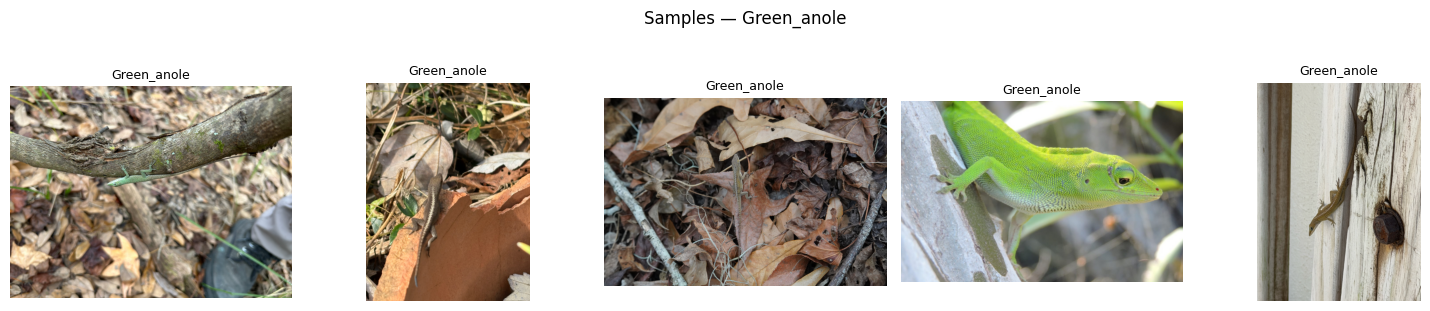

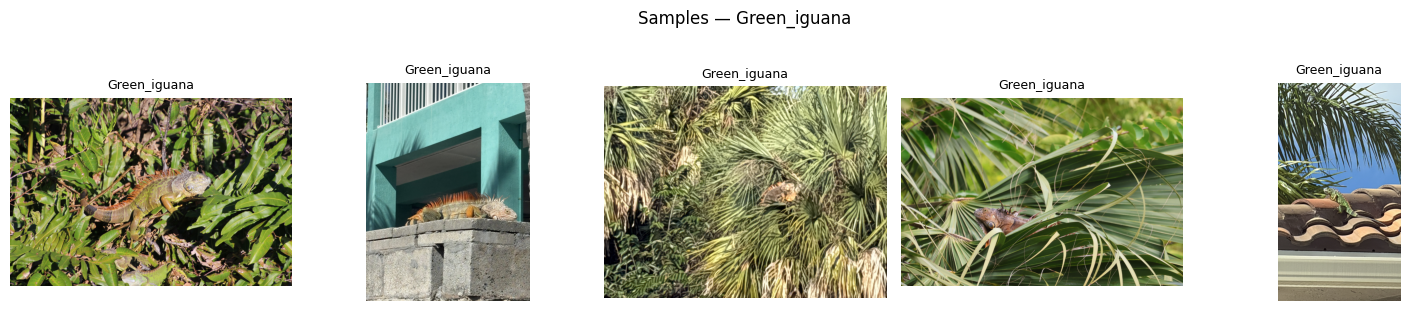

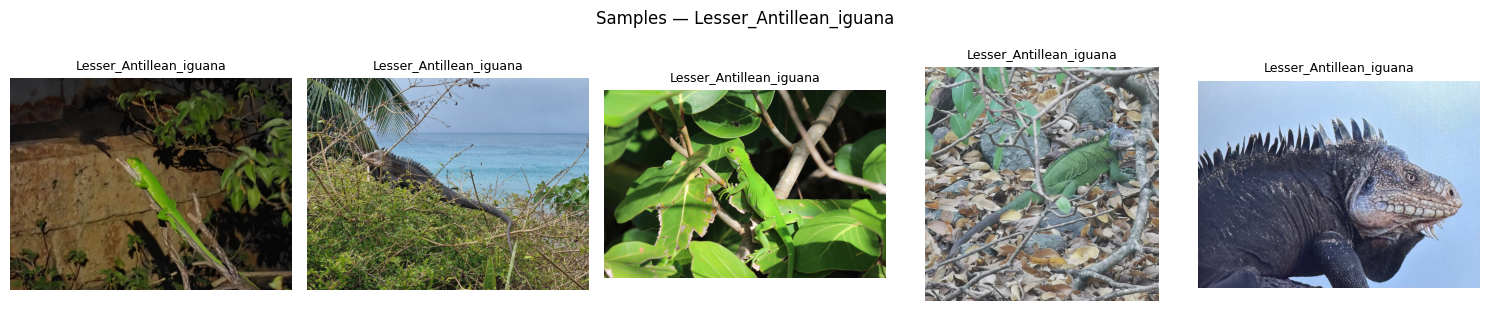

In [5]:
def show_samples(df, class_name, n=5):
    samples = df[df["label"] == class_name].sample(min(n, len(df[df["label"] == class_name])), random_state=42)
    plt.figure(figsize=(15, 3))
    for i, row in enumerate(samples.itertuples()):
        img = Image.open(row.path)
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(row.label, fontsize=9)
    plt.suptitle(f"Samples — {class_name}", y=1.02)
    plt.tight_layout()
    plt.show()

for cls in sorted(train_index["label"].unique()):
    show_samples(train_index, cls, n=5)

## 6. Image Size & Aspect-Ratio Analysis
Understanding the native resolutions helps us choose a sensible `IMG_SIZE` for the model and flag unusually small or large images.

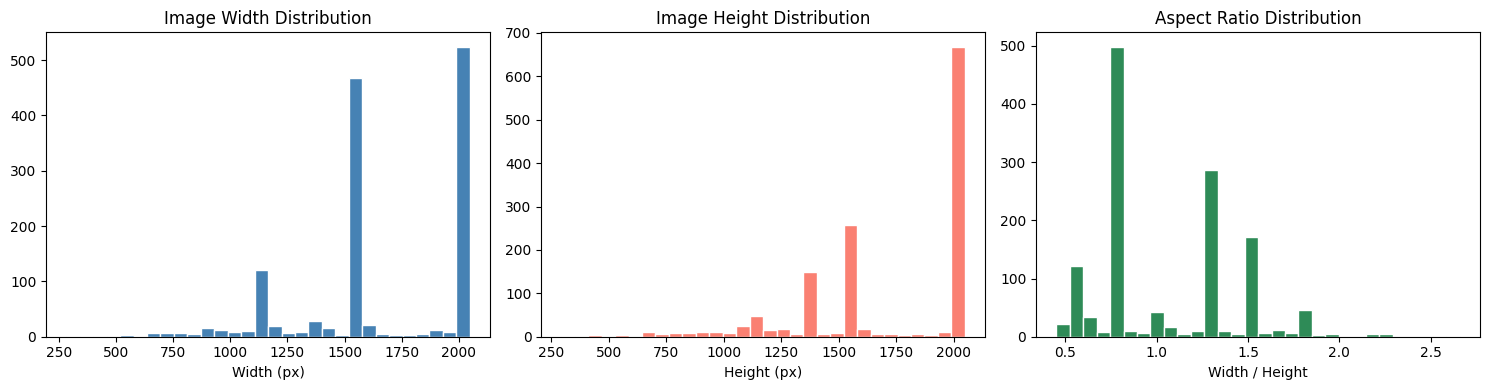

         width   height  aspect_ratio
count  1334.00  1334.00       1334.00
mean   1658.16  1707.15          1.05
std     372.10   392.71          0.39
min     282.00   293.00          0.45
25%    1536.00  1372.75          0.75
50%    1536.00  2020.00          0.75
75%    2048.00  2048.00          1.33
max    2048.00  2048.00          2.66


In [6]:
widths, heights = [], []

for path in train_index["path"]:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

train_index["width"]        = widths
train_index["height"]       = heights
train_index["aspect_ratio"] = train_index["width"] / train_index["height"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_index["width"],        bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width (px)")

axes[1].hist(train_index["height"],       bins=30, color="salmon",    edgecolor="white")
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height (px)")

axes[2].hist(train_index["aspect_ratio"], bins=30, color="seagreen",  edgecolor="white")
axes[2].set_title("Aspect Ratio Distribution")
axes[2].set_xlabel("Width / Height")

plt.tight_layout()
plt.show()

print(train_index[["width", "height", "aspect_ratio"]].describe().round(2))

## 7. Corruption Check
We attempt to verify every image file. Corrupt images would raise an exception and are collected for review.

In [7]:
broken = []

for path in train_index["path"]:
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception as e:
        broken.append((path, str(e)))

print(f"Broken / unreadable images: {len(broken)}")
if broken:
    for p, err in broken:
        print(f"  {p}: {err}")

Broken / unreadable images: 0


## 8. Duplicate Detection & Removal
We check for duplicate entries by filename within the index, and optionally detect visually identical images using file hashing. Duplicates can skew class distributions and inflate training metrics.

In [8]:
import hashlib

# --- 1. Filename-level duplicates ---
filename_dupes = train_index[train_index.duplicated(subset="image_id", keep=False)]
print(f"Filename duplicates: {len(filename_dupes)}")
if not filename_dupes.empty:
    display(filename_dupes)

# --- 2. Content-level duplicates (MD5 hash) ---
def md5(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        h.update(f.read())
    return h.hexdigest()

train_index["hash"] = train_index["path"].apply(md5)

content_dupes = train_index[train_index.duplicated(subset="hash", keep=False)]
print(f"Content (pixel-identical) duplicates: {len(content_dupes)}")
if not content_dupes.empty:
    display(content_dupes.sort_values("hash"))

# --- 3. Drop duplicates, keep first occurrence ---
before = len(train_index)
train_index = train_index.drop_duplicates(subset="hash", keep="first").reset_index(drop=True)
print(f"Removed {before - len(train_index)} duplicate(s). Remaining: {len(train_index)} images.")

Filename duplicates: 0
Content (pixel-identical) duplicates: 293


,image_id,path,label,split,width,height,aspect_ratio,hash
402,Cuban_knight_anole_Anolis_equestris_20.jpg,train\Cuban_knight_anole\Cuban_knight_anole_An...,Cuban_knight_anole,train,1536,2048,0.750000,0099a1174e9832e3884b8f2b1a42cf2c
497,Cuban_knight_anole_Cuban_knight_anole_20.jpg,train\Cuban_knight_anole\Cuban_knight_anole_Cu...,Cuban_knight_anole,train,1536,2048,0.750000,0099a1174e9832e3884b8f2b1a42cf2c
516,Cuban_knight_anole_Cuban_knight_anole_220.jpg,train\Cuban_knight_anole\Cuban_knight_anole_Cu...,Cuban_knight_anole,train,1536,2048,0.750000,0099a1174e9832e3884b8f2b1a42cf2c
1156,Lesser_Antillean_iguana_Lesser_Antillean_iguan...,train\Lesser_Antillean_iguana\Lesser_Antillean...,Lesser_Antillean_iguana,train,2048,1365,1.500366,03f9486200185ad8a8d4add4ad15ced2
1254,Lesser_Antillean_iguana_Lesser_Antillean_iguan...,train\Lesser_Antillean_iguana\Lesser_Antillean...,Lesser_Antillean_iguana,train,2048,1365,1.500366,03f9486200185ad8a8d4add4ad15ced2
...,...,...,...,...,...,...,...,...
866,Green_anole_Green_anole_217.jpg,train\Green_anole\Green_anole_Green_anole_217.jpg,Green_anole,train,1536,2048,0.750000,f1712fec8416fadbf17ad0ba07436d71
843,Green_anole_Green_anole_19.jpg,train\Green_anole\Green_anole_Green_anole_19.jpg,Green_anole,train,1536,2048,0.750000,f1712fec8416fadbf17ad0ba07436d71
397,Cuban_knight_anole_Anolis_equestris_15.jpg,train\Cuban_knight_anole\Cuban_knight_anole_An...,Cuban_knight_anole,train,2048,2048,1.000000,fd74da9e9dba7d9b977423847eede1cc
455,Cuban_knight_anole_Cuban_knight_anole_15.jpg,train\Cuban_knight_anole\Cuban_knight_anole_Cu...,Cuban_knight_anole,train,2048,2048,1.000000,fd74da9e9dba7d9b977423847eede1cc


Removed 173 duplicate(s). Remaining: 1161 images.


## 9. Set Up TensorFlow Image Datasets
We use `image_dataset_from_directory` for an 80/20 train-validation split. Images are resized to 300 × 300 (up from 224) to preserve the fine-grained scale patterns and colour details that distinguish closely related iguana species.

In [9]:
IMG_SIZE   = (300, 300)  # increased from 224 to preserve fine-grained scale/colour detail
BATCH_SIZE = 64

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
print("Classes found:", class_names)

Found 1334 files belonging to 7 classes.
Using 1068 files for training.
Found 1334 files belonging to 7 classes.
Using 266 files for validation.
Classes found: ['Black_spiny_tailed_iguana', 'Brown_anole', 'Cuban_knight_anole', 'Desert_iguana', 'Green_anole', 'Green_iguana', 'Lesser_Antillean_iguana']


## 10. Performance Optimisation
We cache and prefetch the datasets to maximise GPU utilisation. Augmentation is defined inside the model in the next section.

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 11. Build the Model — MobileNetV2 Transfer Learning
Augmentation layers are defined *inside* the model so Keras automatically disables them during validation and inference. We add `RandomContrast` and `RandomBrightness` to the existing flip/rotation/zoom/translation layers, targeting the lighting variation seen across iguana species photos.

In [11]:
num_classes = len(class_names)

# Augmentation lives inside the model so it is automatically
# disabled at inference time (training=False).
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    layers.RandomContrast(0.2),   # helps with iguana lighting variation
    layers.RandomBrightness(0.2), # helps with iguana lighting variation
], name="data_augmentation")

base_model = tf.keras.applications.EfficientNetB3(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False  # freeze backbone for phase-1 training

model = keras.Sequential([
    data_augmentation,
    layers.Lambda(tf.keras.applications.efficientnet.preprocess_input,
                  name="efficientnet_preprocess"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, name="outputs"),
], name="lizard_classifier")

model.summary()

Model: "lizard_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_preprocess         │ ?                      │   0 (unbuilt) │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,783,535 (41.14 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 10,783,535 (41.14 MB)

## 12. Compile & Train — Phase 1 (Frozen Backbone)
We use focal loss instead of standard cross-entropy. Focal loss adds a modulating factor that down-weights confident correct predictions and focuses training on hard, misclassified examples — directly addressing the Brown_anole and iguana confusion. Class weights are retained on top for the under-represented classes.

In [12]:
from sklearn.utils.class_weight import compute_class_weight

unique_labels = sorted(set(train_index["label"]))
label_to_idx  = {name: i for i, name in enumerate(unique_labels)}
y_train       = train_index["label"].map(label_to_idx).values

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(unique_labels)),
    y=y_train,
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Class weights:")
for idx, name in enumerate(unique_labels):
    print(f"  {name}: {class_weight_dict[idx]:.3f}")

# Custom focal loss — compatible with all TF/Keras versions.
# Focal loss down-weights easy/confident predictions (gamma=2 is standard)
# so training focuses on the hard iguana cases the model keeps confusing.
def focal_loss(gamma=2.0):
    cce = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True, reduction="none"
    )
    def loss_fn(y_true, y_pred):
        ce_loss = cce(y_true, y_pred)
        probs   = tf.nn.softmax(y_pred)
        y_true_idx = tf.cast(y_true, tf.int32)
        p_t = tf.gather(probs, y_true_idx, batch_dims=1)
        focal_factor = tf.pow(1.0 - p_t, gamma)
        return tf.reduce_mean(focal_factor * ce_loss)
    return loss_fn

model.compile(
    optimizer="adam",
    loss=focal_loss(gamma=2.0),
    metrics=["accuracy"],
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=12, restore_best_weights=True, verbose=1
)

EPOCHS = 40
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[reduce_lr, early_stopping],
)

Class weights:
  Black_spiny_tailed_iguana: 0.976
  Brown_anole: 0.911
  Cuban_knight_anole: 1.050
  Desert_iguana: 1.056
  Green_anole: 1.098
  Green_iguana: 0.932
  Lesser_Antillean_iguana: 1.005
Epoch 1/40

17/17 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.2921 - loss: 1.3006 - val_accuracy: 0.5188 - val_loss: 0.9511 - learning_rate: 0.0010
Epoch 2/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.4710 - loss: 0.9273 - val_accuracy: 0.5827 - val_loss: 0.7121 - learning_rate: 0.0010
Epoch 3/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5468 - loss: 0.7762 - val_accuracy: 0.6015 - val_loss: 0.6117 - learning_rate: 0.0010
Epoch 4/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5702 - loss: 0.7163 - val_accuracy: 0.6353 - val_loss: 0.5453 - learning_rate: 0.0010
Epoch 5/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5936 - loss: 0.6586 - val_accuracy: 0.6729 - val_loss: 0.5088 - learning_rate: 0.0010
Epoch 6/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step -

## 13. Skip Fine-Tuning
The fine-tuning phase was removed because it reduced both training and validation accuracy in this run. We keep the frozen-backbone model from phase 1 as the final model and plot its history directly.

In [13]:
# Keep the phase-1 model as the final model.
def get_series(h, *keys):
    for k in keys:
        if k in h.history:
            return h.history[k]
    return []

acc = get_series(history, "accuracy", "acc", "sparse_categorical_accuracy")
val_acc = get_series(history, "val_accuracy", "val_acc", "val_sparse_categorical_accuracy")
loss = get_series(history, "loss")
val_loss = get_series(history, "val_loss")
epochs_range = range(len(loss))

## 14. Training & Validation Curves
These curves show the frozen-backbone training run only.

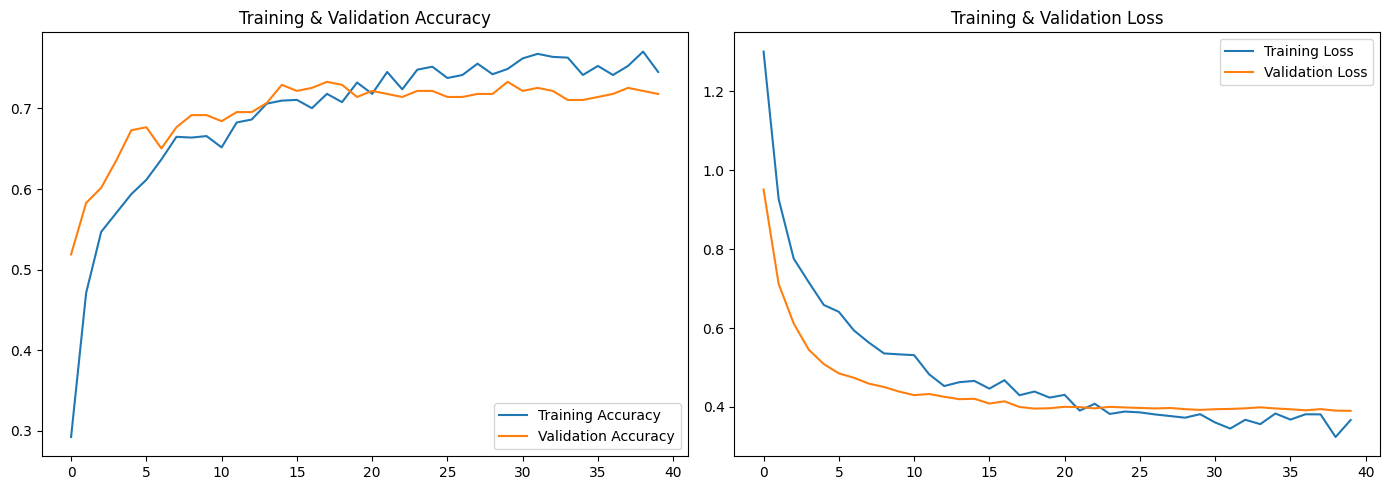

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, train_vals, val_vals, metric in zip(
    axes,
    [acc,  loss],
    [val_acc, val_loss],
    ["Accuracy", "Loss"],
):
    ax.plot(epochs_range, train_vals, label=f"Training {metric}")
    ax.plot(epochs_range, val_vals,   label=f"Validation {metric}")
    ax.set_title(f"Training & Validation {metric}")
    ax.legend(loc="lower right" if metric == "Accuracy" else "upper right")

plt.tight_layout()
plt.show()

## 15. Confusion Matrix
Confusion matrix using direct model predictions on the validation set.

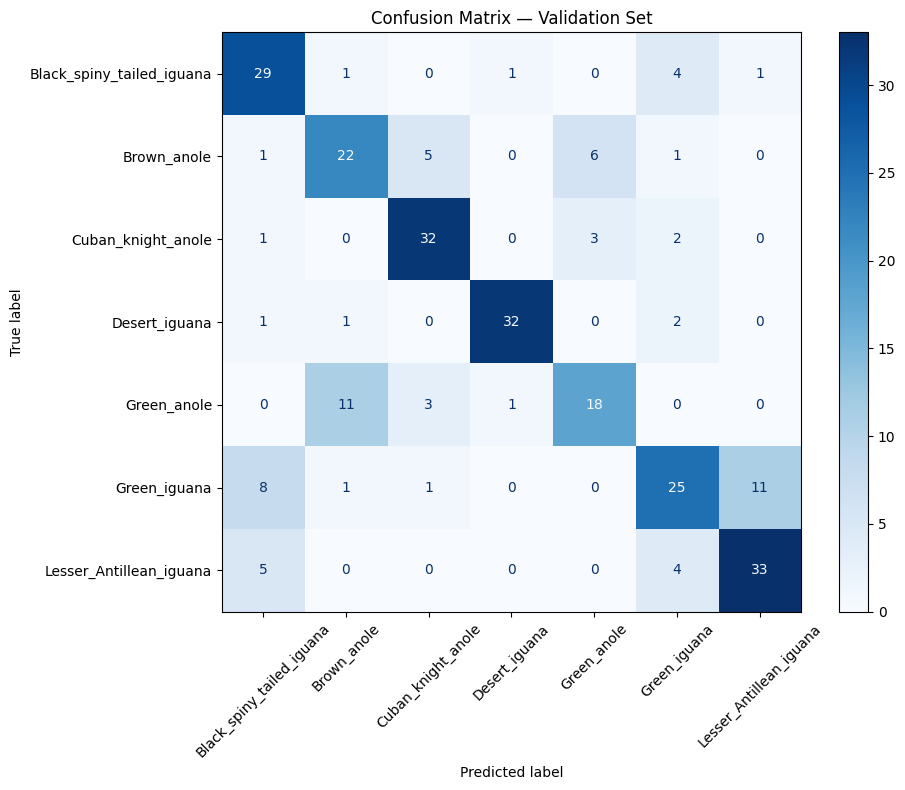

7728

In [17]:
# Gather validation predictions
pred_classes_list = []
val_labels_list = []

for images, labels in val_ds:
    logits = model(images, training=False)
    pred_classes_list.extend(np.argmax(logits.numpy(), axis=1))
    val_labels_list.extend(labels.numpy())
    del logits
    gc.collect()

# Compute confusion matrix
cm = confusion_matrix(val_labels_list, pred_classes_list)
del pred_classes_list, val_labels_list
gc.collect()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, ax=ax)
ax.set_title("Confusion Matrix — Validation Set")
fig.tight_layout()
plt.show()

# Cleanup after showing
plt.close('all')
del cm, disp, fig
gc.collect()


## 16. Generate Kaggle Submission
We write the predictions to `submission.csv`.

In [23]:
# Load test data and create submission
test_df = pd.read_csv("test.csv")
print(f"Test set size: {len(test_df)}")

# Get the expected input size from the model
input_shape = model.input_shape
img_height, img_width = input_shape[1], input_shape[2]
print(f"Model expects input size: {img_height}x{img_width}")

# Create test dataset
test_image_paths = [f"test/{test_id}.jpg" for test_id in test_df["id"]]
test_images = []
for path in test_image_paths:
    img = tf.keras.preprocessing.image.load_img(path, target_size=(img_height, img_width))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    test_images.append(img_array)

test_images_tensor = tf.stack(test_images)
print(f"Test images tensor shape: {test_images_tensor.shape}")

# Make predictions in batches to avoid OOM
batch_size = 32
all_logits = []

for i in range(0, len(test_images_tensor), batch_size):
    batch = test_images_tensor[i:i + batch_size]
    batch_logits = model(batch, training=False)
    all_logits.append(batch_logits.numpy())
    del batch_logits
    print(f"Processed {min(i + batch_size, len(test_images_tensor))}/{len(test_images_tensor)}")

logits = np.concatenate(all_logits, axis=0)
pred_classes = np.argmax(logits, axis=1)

# Convert predictions back to numeric class IDs
idx_to_label = {i: name for i, name in enumerate(unique_labels)}
name_to_id = dict(zip(classes_df["Class_name"], classes_df["Class"]))
pred_labels = [name_to_id[idx_to_label[idx]] for idx in pred_classes]

# Create submission dataframe
submission_df = pd.DataFrame({
    "id": test_df["id"],
    "label": pred_labels
})

print("\nSubmission preview:")
print(submission_df.head())

# Save submission
submission_df.to_csv("submission.csv", index=False)
print(f"\nSubmission saved to submission.csv")

Test set size: 326
Model expects input size: 300x300
Test images tensor shape: (326, 300, 300, 3)
Processed 32/326
Processed 64/326
Processed 96/326
Processed 128/326
Processed 160/326
Processed 192/326
Processed 224/326
Processed 256/326
Processed 288/326
Processed 320/326
Processed 326/326

Submission preview:
   id  label
0   1      6
1   2      5
2   3      1
3   4      5
4   5      0

Submission saved to submission.csv
